In [2]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import muspan as ms
from itertools import zip_longest
from typing import List, Tuple, Optional
import math
from functools import partial
import seaborn as sns
from scipy import stats
import pathlib

In [ ]:
## Read in domains with Mets
# Make list of file names
directory = pathlib.Path("../outputs/In_out")
i=0
list_of_files = []
for item in directory.rglob("*"):
    if item.is_file():
            if str(item) != str(directory)+'/.DS_Store':
                list_of_files.append(str(item))
            i+=1
names = [x.replace('../domains_with_mets/', '').replace('.muspan', '') for x in list_of_files]

# make reference lists of met numbers and corresponding list of domain names (should really be a dict but it was too late to change it)
met_nos = [1,1,2,3,7,17,2,23,13,4]
domains_order = ['AKPT_Liver_Mets_4d_2_Region_1', 
                'AKPT_Liver_Mets_4d_3_Region_1', 
                'AKPT_Liver_Mets_4d_1_Region_2', 
                'AKPT_Liver_Mets_4d_5_Region_1',
                'AKPT_Liver_Mets_28d_2_Region_2', 
                'AKPT_Liver_Mets_28d_1_Region_1', 
                'AKPT_Liver_Mets_4d_1_Region_1',
                'AKPT_Liver_Mets_28d_2_Region_1',
                'AKPT_Liver_Mets_28d_3_Region_1',
                'AKPT_Liver_Mets_28d_1_Region_2']

# read in domains from file names
list_of_domains = []
for i in range(len(list_of_files)):
    list_of_domains.append(ms.io.load_domain(list_of_files[i], print_summary=False))

Note: plotting currently set up for three cell types of interest, could be generalised with a bit more time, or just tweaked as required. Currently the kdes are scaled by the depth of the met but I've added a commented line that can be substituted in

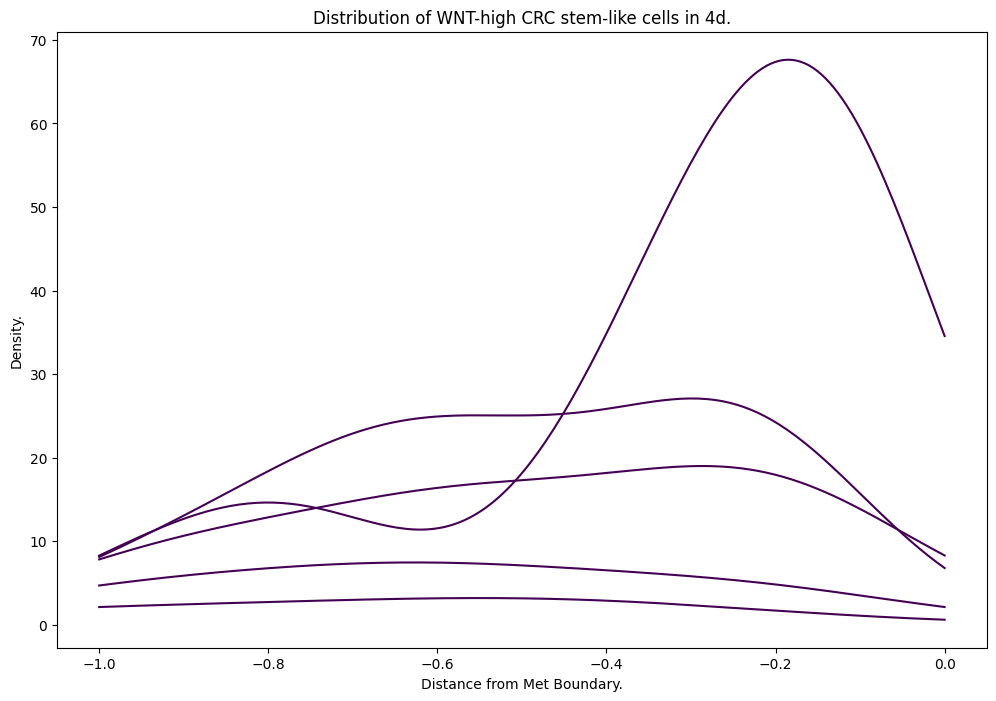

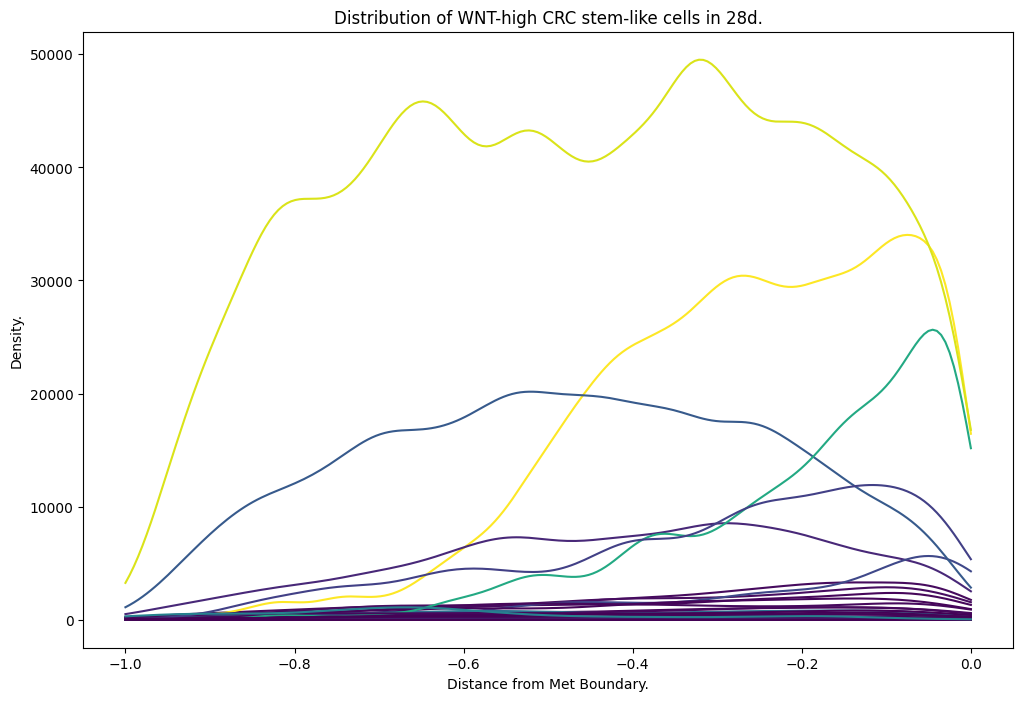

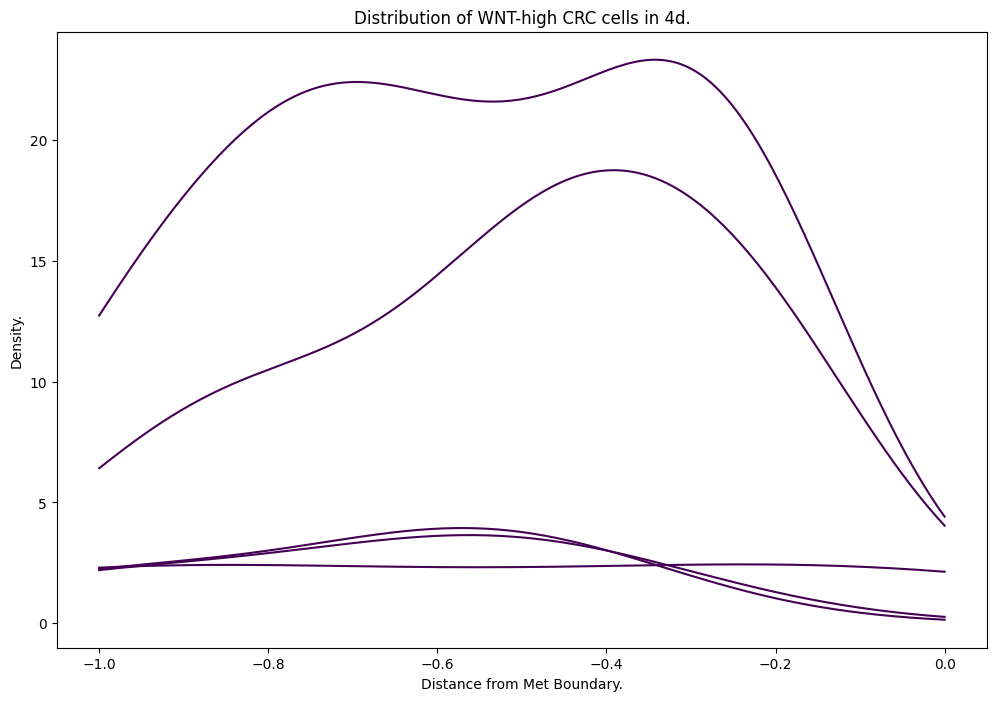

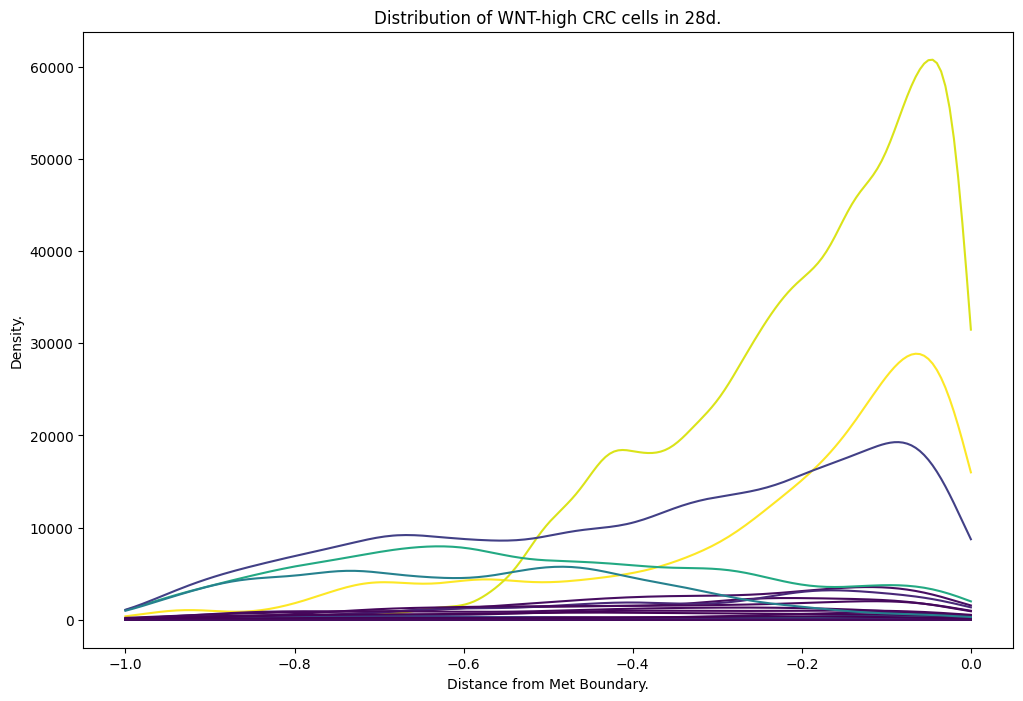

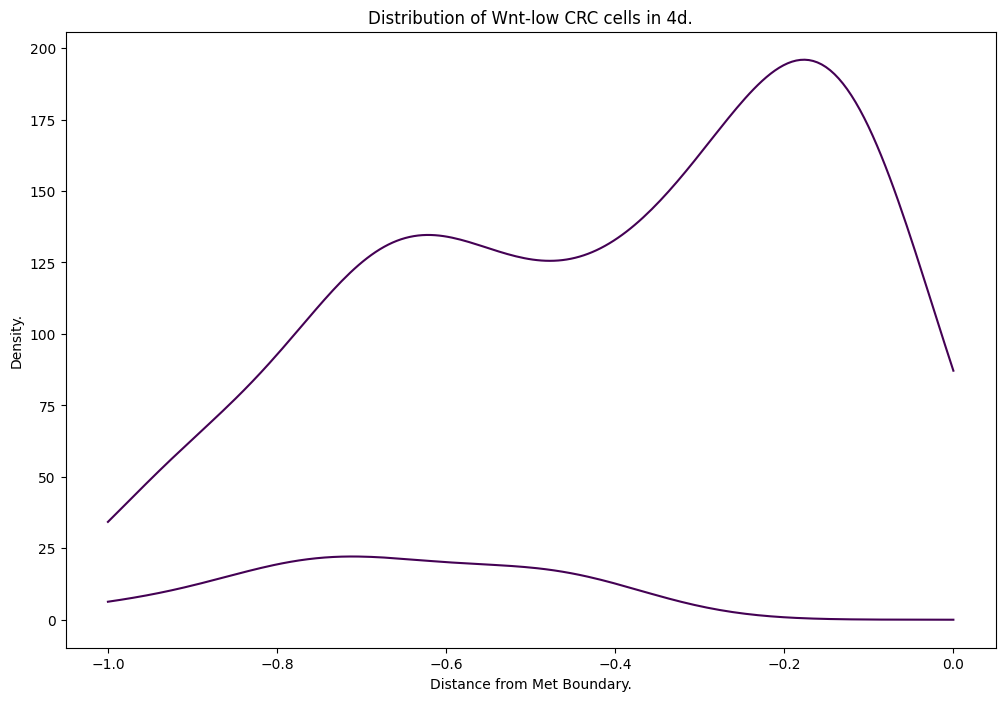

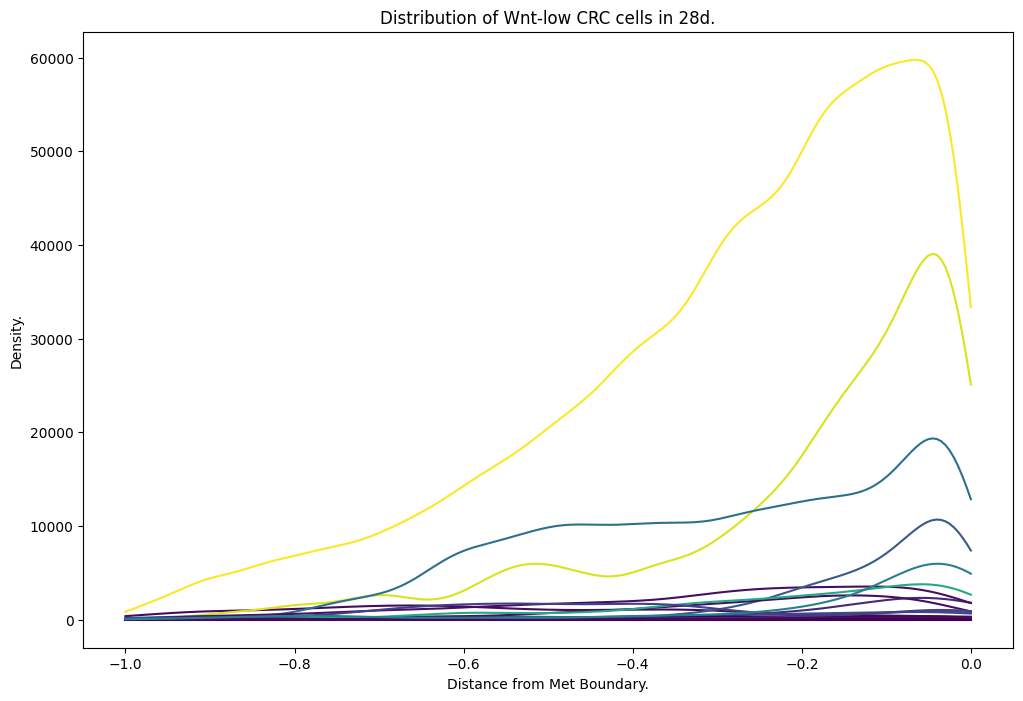

In [ ]:
# specify cell type of interest
celltypes = ['WNT-high CRC stem-like cells', 'WNT-high CRC cells', 'Wnt-low CRC cells']
label_name = 'Detailed celltype (liver)'

colours = ['#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000', '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000', '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000']
list_of_axes = []
list_of_figs = []
list_of_max_met_dists = []
list_of_max_out_dists = []
all_met_distances = []
all_regional_max_met_dists = []
for dom in range(len(list_of_domains)):
    domain = list_of_domains[dom]
    met_no = met_nos[domains_order.index(str(domain.name))]
    one_domain_met_distances = []
    one_domain_out_distances = []
    for region_no in range(met_no):
        met_distances = np.load('../outputs/Useful_Data/'+str(domain.name)+'_inside_Met_'+str(region_no+1)+'.npy', allow_pickle=True)
        one_domain_met_distances.append(met_distances)
    all_met_distances.append(one_domain_met_distances)

# This will need changing if you have more or less than 3 cell types of interest
for dom in range(6):
    # figures
    fig, axes = plt.subplots(1, 1, figsize=(12, 8))
    ages = ['4d', '28d']
    if (dom == 0) or (dom == 1):
        axes.set_title('Distribution of ' + str(celltypes[0]) + ' in ' + str(ages[dom]) + '.')
    elif (dom == 2) or (dom == 3):
        axes.set_title('Distribution of ' + str(celltypes[1]) + ' in ' + str(ages[dom-2]) + '.')
    elif (dom == 4) or (dom == 5):
        axes.set_title('Distribution of ' + str(celltypes[2]) + ' in ' + str(ages[dom-4]) + '.')
    axes.set_xlabel('Distance from Met Boundary.')
    axes.set_ylabel('Density.')
    list_of_axes.append(axes)
    list_of_figs.append(fig)
    
all_met_areas = []
max_areas = []
for dom in range(len(list_of_domains)):
    domain = list_of_domains[dom]
    met_no = met_nos[domains_order.index(str(domain.name))]
    domain.estimate_boundary('rectangle')
    # make list of met distances
    max_met_dist=0
    regional_max_met_dists = []
    shape_cell_distances = all_met_distances[dom]
    met_areas = []
    for region_no in range(met_no):
        distances = shape_cell_distances[region_no][1]
        regional_max_met_dists.append(np.max(distances))
        if np.max(distances) > max_met_dist:
            max_met_dist = np.max(distances)
        met_areas.append(ms.geometry.area(domain, population=('collection', 'Metastasis '+str(region_no+1)))[0])
    all_met_areas.append(met_areas)
    max_areas.append(np.max(met_areas))        
    list_of_max_met_dists.append(max_met_dist)
    all_regional_max_met_dists.append(regional_max_met_dists)

max_met_area = np.max(max_areas)

all_domains_met_distances_joined = []
for dom in range(len(list_of_domains)):
    domain = list_of_domains[dom]
    met_no = met_nos[domains_order.index(str(domain.name))]
    if '4d' in str(domain.name):
        age = 0
    elif '28d' in str(domain.name):
        age = 1
    else:
        print('Something went wrong - should have 28d or 4d in name')
    for celltype_no in range(len(celltypes)):
        celltype = celltypes[celltype_no]
        all_relevant_distances = []
        overall_x_min = 0
        all_normalised_distances = []
        all_kdes = []
        all_regions_distances = []
        for region_no in range(met_no):
            query_cell = ms.query.query(domain, ('label', label_name), 'is', celltype)
            specific_cell_IDs = ms.query.return_object_IDs_from_query_like(domain,query_cell,bypass_checks=True)

            shape_cell_distances = all_met_distances[dom][region_no]
            distances = [shape_cell_distances[1][i] for i in range(len(shape_cell_distances[0])) if shape_cell_distances[0][i] in specific_cell_IDs]
            all_regions_distances.append(distances)
            if len(distances) > 1:
                x_max = np.max(distances)
                x_min = -x_max
                if x_min < overall_x_min:
                    overall_x_min = x_min
                
                area = all_met_areas[dom][region_no]
                color_temp = plt.cm.viridis(area/max_met_area)
                normalised_distances = distances/np.max(distances)
                kde = stats.gaussian_kde(normalised_distances)
                x_eval = np.linspace(0, 1, num=200)
                array_temp = np.array(x_eval)*-1
                x = list(array_temp)
                # If you'd like unscaled lines not scaled by size uncomment the following and change it for the below line
                # list_of_axes[2*celltype_no+age].plot(x, kde(x_eval), color = color_temp)
                list_of_axes[2*celltype_no+age].plot(x, kde(x_eval)*len(distances), color = color_temp)

Optional Extension to group mets below a certain threshold and plot the average kde for them to reduce number of lines

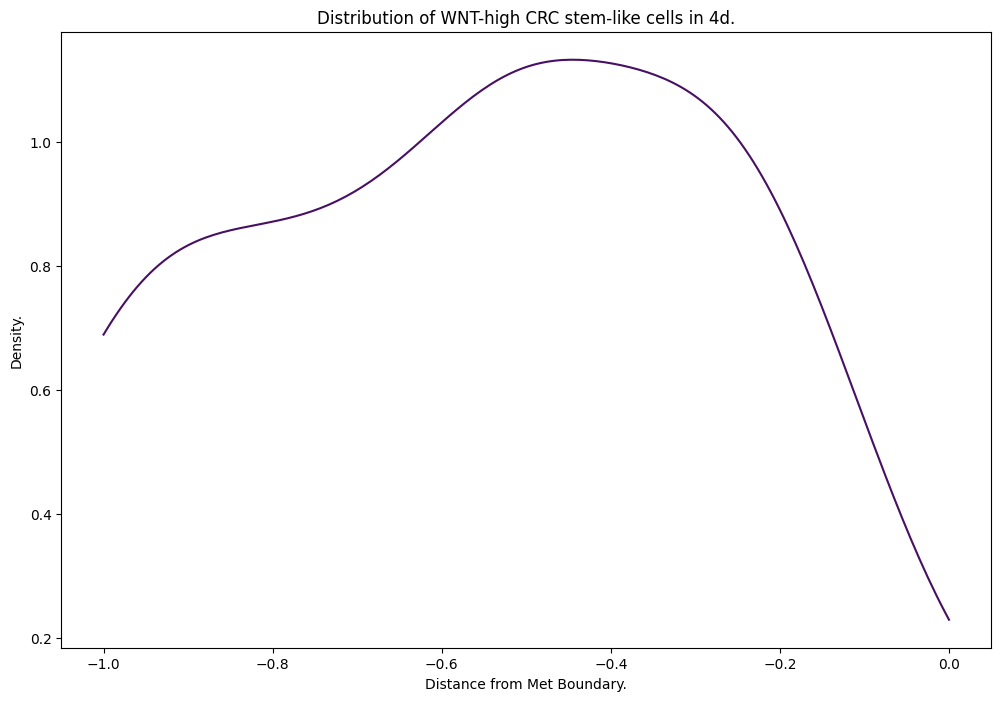

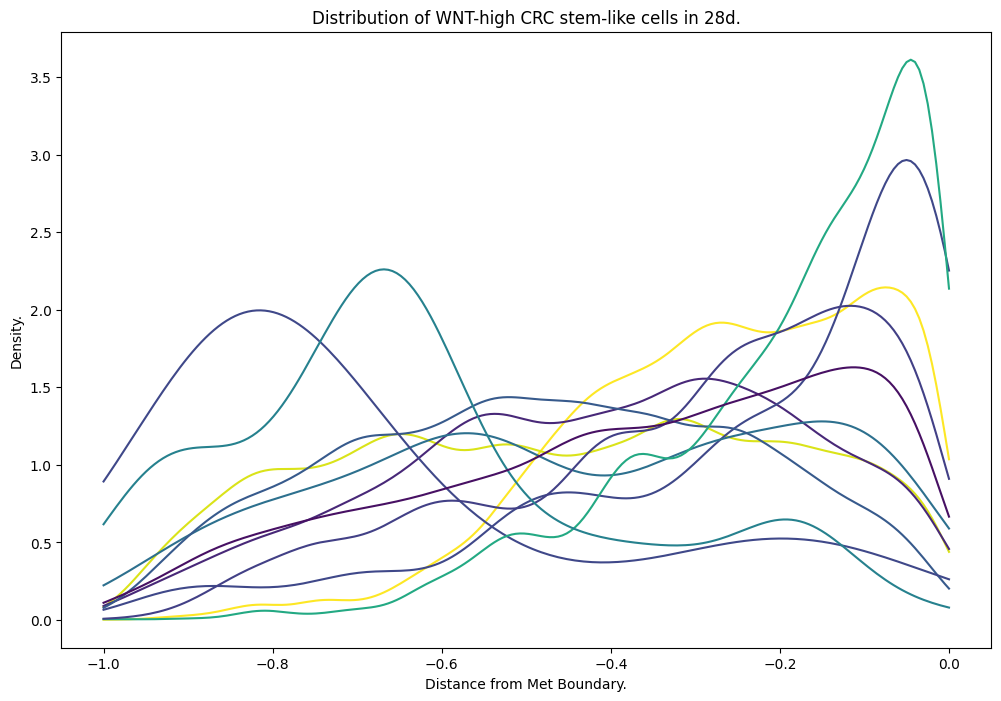

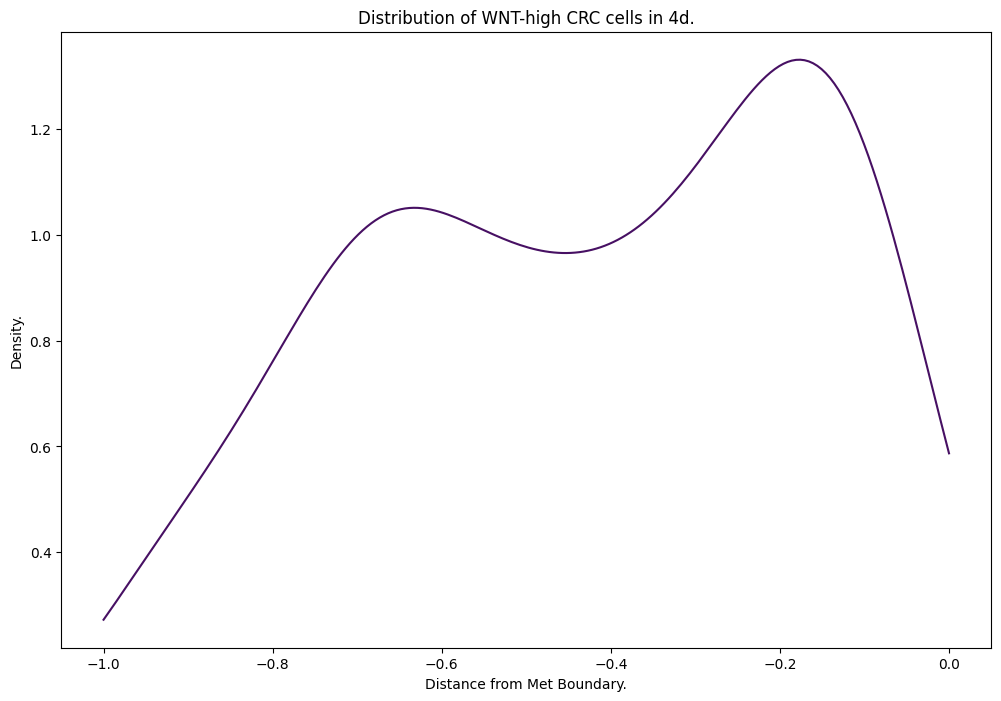

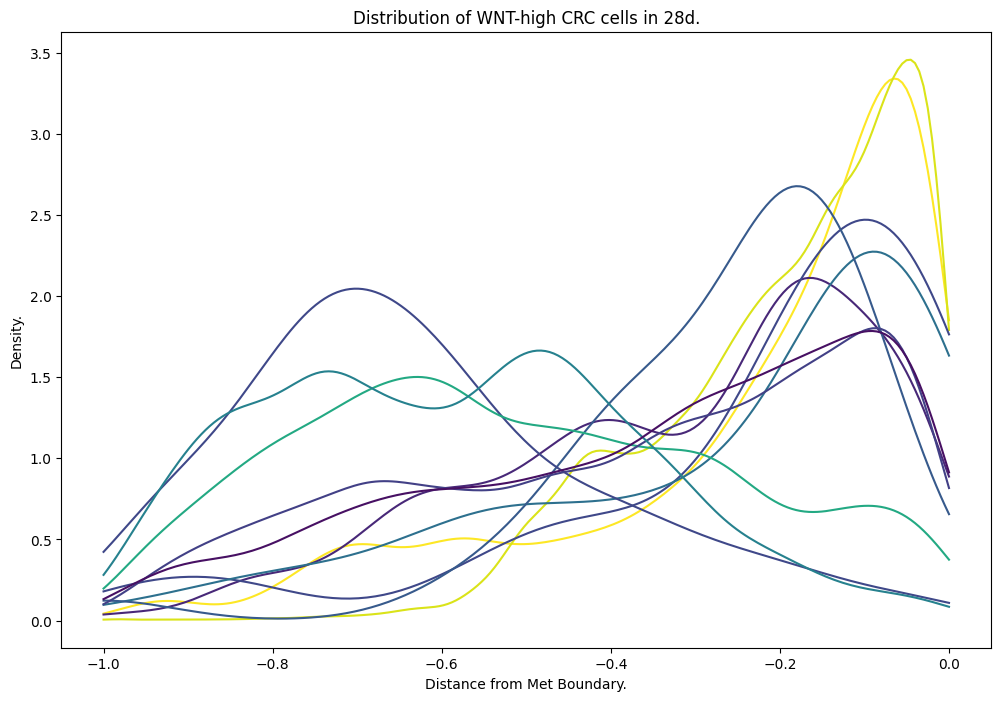

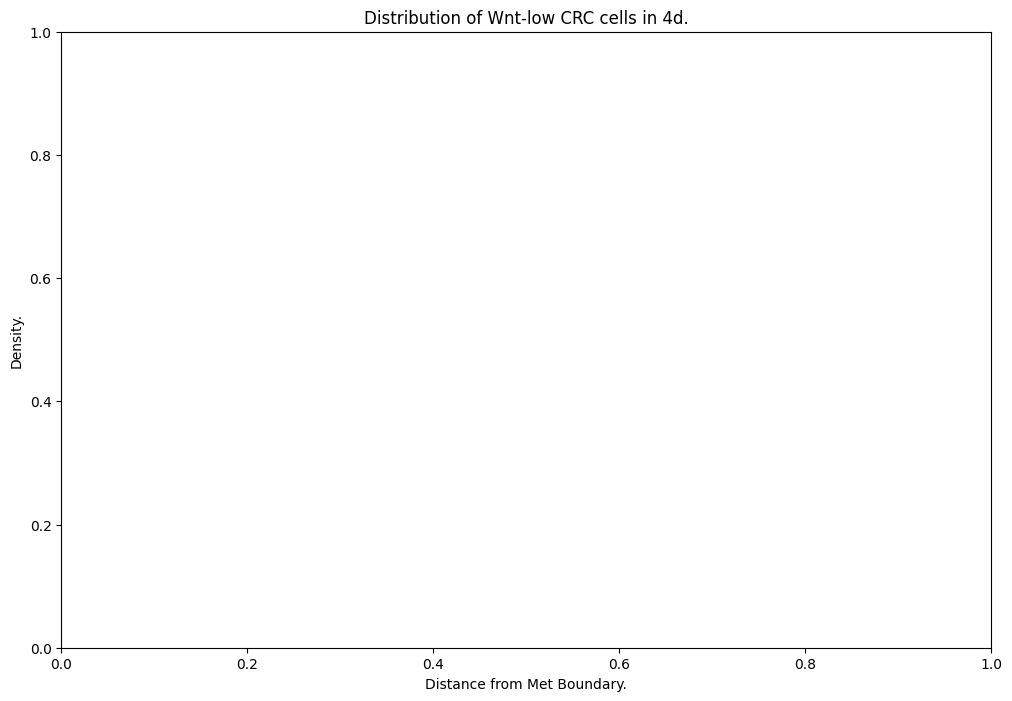

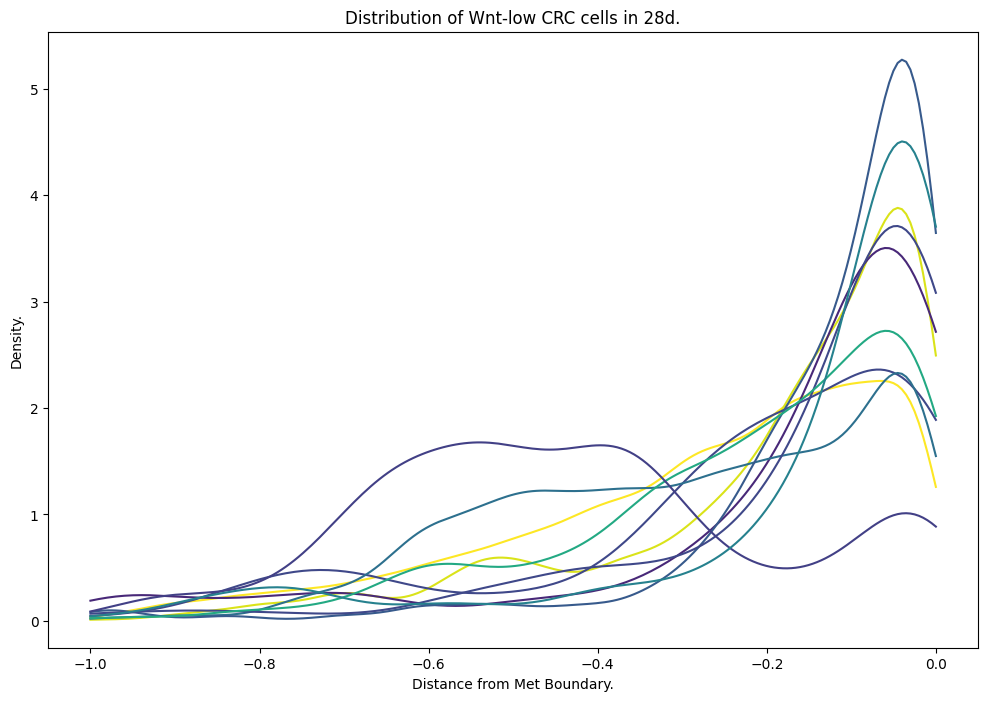

In [ ]:
# specify threshold
threshold = 500000
# specify cell type of interest
celltypes = ['WNT-high CRC stem-like cells', 'WNT-high CRC cells', 'Wnt-low CRC cells']
label_name = 'Detailed celltype (liver)'

colours = ['#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000', '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000', '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000']
list_of_axes = []
list_of_figs = []
list_of_max_met_dists = []
list_of_max_out_dists = []
all_met_distances = []
all_out_distances = []
all_regional_max_met_dists = []
for dom in range(len(list_of_domains)):
    domain = list_of_domains[dom]
    met_no = met_nos[domains_order.index(str(domain.name))]
    one_domain_met_distances = []
    one_domain_out_distances = []
    for region_no in range(met_no):
        met_distances = np.load('../outputs/Useful_Data/'+str(domain.name)+'_inside_Met_'+str(region_no+1)+'.npy', allow_pickle=True)
        one_domain_met_distances.append(met_distances)
    out_distances = np.load('../outputs/Useful_Data/'+str(domain.name)+'_outside_to_all_Mets.npy', allow_pickle=True)
    # one_domain_out_distances.append(out_distances)
    all_out_distances.append(out_distances)
    all_met_distances.append(one_domain_met_distances)

for dom in range(6):
    # figures
    fig, axes = plt.subplots(1, 1, figsize=(12, 8))
    ages = ['4d', '28d']
    if (dom == 0) or (dom == 1):
        axes.set_title('Distribution of ' + str(celltypes[0]) + ' in ' + str(ages[dom]) + '.')
    elif (dom == 2) or (dom == 3):
        axes.set_title('Distribution of ' + str(celltypes[1]) + ' in ' + str(ages[dom-2]) + '.')
    elif (dom == 4) or (dom == 5):
        axes.set_title('Distribution of ' + str(celltypes[2]) + ' in ' + str(ages[dom-4]) + '.')
    axes.set_xlabel('Distance from Met Boundary.')
    axes.set_ylabel('Density.')
    list_of_axes.append(axes)
    list_of_figs.append(fig)
    
all_met_areas = []
max_areas = []
for dom in range(len(list_of_domains)):
    domain = list_of_domains[dom]
    met_no = met_nos[domains_order.index(str(domain.name))]
    max_met_dist=0
    regional_max_met_dists = []
    shape_cell_distances = all_met_distances[dom]
    met_areas = []
    for region_no in range(met_no):
        distances = shape_cell_distances[region_no][1]
        regional_max_met_dists.append(np.max(distances))
        if np.max(distances) > max_met_dist:
            max_met_dist = np.max(distances)
        met_areas.append(ms.geometry.area(domain, population=('collection', 'Metastasis '+str(region_no+1)))[0])
    all_met_areas.append(met_areas)
    max_areas.append(np.max(met_areas))        
    list_of_max_met_dists.append(max_met_dist)
    all_regional_max_met_dists.append(regional_max_met_dists)

max_met_area = np.max(max_areas)
all_domains_met_distances_joined = []
celltype_1_young = []
celltype_2_young = []
celltype_3_young = []
celltype_1_old = []
celltype_2_old = []
celltype_3_old = []
for dom in range(len(list_of_domains)):
    domain = list_of_domains[dom]
    met_no = met_nos[domains_order.index(str(domain.name))]
    if '4d' in str(domain.name):
        age = 0
    elif '28d' in str(domain.name):
        age = 1
    else:
        print('Something went wrong - should have 28d or 4d in name')
    for celltype_no in range(len(celltypes)):
        young_small_area_dists = []
        old_small_area_dists = []
        celltype = celltypes[celltype_no]
        all_relevant_distances = []
        overall_x_min = 0
        all_normalised_distances = []
        all_kdes = []
        all_regions_distances = []
        for region_no in range(met_no):
            query_cell = ms.query.query(domain, ('label', label_name), 'is', celltype)
            specific_cell_IDs = ms.query.return_object_IDs_from_query_like(domain,query_cell,bypass_checks=True)

            shape_cell_distances = all_met_distances[dom][region_no]
            distances = [shape_cell_distances[1][i] for i in range(len(shape_cell_distances[0])) if shape_cell_distances[0][i] in specific_cell_IDs]
            all_regions_distances.append(distances)
            if len(distances) > 1:
                x_max = np.max(distances)
                x_min = -x_max
                if x_min < overall_x_min:
                    overall_x_min = x_min
                
                area = all_met_areas[dom][region_no]
                color_temp = plt.cm.viridis(area/max_met_area)
                normalised_distances = distances/np.max(distances)
                if area < threshold:
                    if celltype_no == 1:
                        if age == 0:
                            celltype_1_young.extend(normalised_distances)
                        else:
                            celltype_1_old.extend(normalised_distances)
                    elif celltype_no == 2:
                        if age == 0:
                            celltype_2_young.extend(normalised_distances)
                        else:
                            celltype_2_old.extend(normalised_distances)
                    if celltype_no == 3:
                        if age == 0:
                            celltype_3_young.extend(normalised_distances)
                        else:
                            celltype_3_old.extend(normalised_distances)
                else:
                    kde = stats.gaussian_kde(normalised_distances)
                    x_eval = np.linspace(0, 1, num=200)
                    array_temp = np.array(x_eval)*-1
                    x = list(array_temp)
                    list_of_axes[2*celltype_no+age].plot(x, kde(x_eval), color = color_temp)
for celltype_no in range(len(celltypes)):
    celltype = celltypes[celltype_no]
    for age in range(2):
        if celltype_no == 0:
            if age == 0:
                if len(celltype_1_young) > 1:
                    kde = stats.gaussian_kde(celltype_1_young)
                    x_eval = np.linspace(0, 1, num=200)
                    color_temp = plt.cm.viridis(threshold/max_met_area)
                    array_temp = np.array(x_eval)*-1
                    x = list(array_temp)
                    list_of_axes[2*celltype_no+age].plot(x, kde(x_eval), color = color_temp)
            elif age == 1:
                if len(celltype_1_old) > 1:                
                    kde = stats.gaussian_kde(celltype_1_old)
                    x_eval = np.linspace(0, 1, num=200)
                    array_temp = np.array(x_eval)*-1
                    color_temp = plt.cm.viridis(threshold/max_met_area)
                    x = list(array_temp)
                    list_of_axes[2*celltype_no+age].plot(x, kde(x_eval), color = color_temp)
        if celltype_no == 1:
            if age == 0:
                if len(celltype_2_young) > 1: 
                    kde = stats.gaussian_kde(celltype_2_young)
                    x_eval = np.linspace(0, 1, num=200)
                    color_temp = plt.cm.viridis(threshold/max_met_area)
                    array_temp = np.array(x_eval)*-1
                    x = list(array_temp)
                    list_of_axes[2*celltype_no+age].plot(x, kde(x_eval), color = color_temp)
            elif age == 1:
                if len(celltype_2_old) > 1: 
                    kde = stats.gaussian_kde(celltype_2_old)
                    x_eval = np.linspace(0, 1, num=200)
                    array_temp = np.array(x_eval)*-1
                    color_temp = plt.cm.viridis(threshold/max_met_area)
                    x = list(array_temp)
                    list_of_axes[2*celltype_no+age].plot(x, kde(x_eval), color = color_temp)
        if celltype_no == 2:
            if age == 0:
                if len(celltype_3_young) > 1: 
                    kde = stats.gaussian_kde(celltype_3_young)
                    x_eval = np.linspace(0, 1, num=200)
                    color_temp = plt.cm.viridis(threshold/max_met_area)
                    array_temp = np.array(x_eval)*-1
                    x = list(array_temp)
                    list_of_axes[2*celltype_no+age].plot(x, kde(x_eval), color = color_temp)
            elif age == 1:
                if len(celltype_3_old) > 1: 
                    kde = stats.gaussian_kde(celltype_3_old)
                    x_eval = np.linspace(0, 1, num=200)
                    array_temp = np.array(x_eval)*-1
                    color_temp = plt.cm.viridis(threshold/max_met_area)
                    x = list(array_temp)
                    list_of_axes[2*celltype_no+age].plot(x, kde(x_eval), color = color_temp)